# Linear Mixed Models — When Your Data Comes in Clusters
*Data 200 · Applied Statistical Analysis · Instructor: Aayush Regmi*

---

Every regression model we have built so far has quietly assumed that
**every row of the dataset is independent of every other row**. That
assumption holds for a clean random sample. It almost *never* holds
for the data you'll see in real life:

- Students are nested inside **classrooms**, classrooms inside
  **schools**.
- Patients are measured **multiple times** over weeks of treatment.
- Plots of land sit inside the **same farm**, farms inside the same
  **region**.

In all three cases, observations within a cluster are **correlated**.
Pretending otherwise — by running plain OLS — quietly inflates your
false-positive rate and gives you confidence intervals that are too
small.

**Linear Mixed Models (LMMs)** are the principled fix. They let us
estimate a population-wide pattern (the **fixed effect**) while *also*
acknowledging that each cluster has its own quirks (the **random
effect**).


## Learning Objectives

By the end of this notebook you'll be able to:

1. Recognise **clustered / hierarchical / repeated-measures** data
   and explain why plain OLS misbehaves on it.
2. Distinguish **fixed effects** (population-wide) from **random
   effects** (cluster-specific deviations).
3. Fit a **random-intercept** mixed model with `statsmodels.mixedlm`
   and read its summary.
4. Add **random slopes** when the predictor's effect itself varies
   between clusters.
5. Compute the **Intraclass Correlation Coefficient (ICC)** and use it
   to decide whether a mixed model is needed.
6. Apply mixed models to **repeated measurements** of the same unit
   over time.
7. Know where **Generalized Linear Mixed Models (GLMMs)** fit in when
   the outcome is not Gaussian.


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
rng = np.random.default_rng(7)


## 1. Why Plain OLS Isn't Enough for Clustered Data

Linear regression's standard errors and p-values rely on this
assumption from the [Linear Regression notebook](LinearRegression.md):

> **Each observation $(x_i, y_i)$ is independent of every other.**

Now think about a study of student exam scores from **10 schools**.
Two students from the *same* school share more than two students
picked at random — same teachers, same neighbourhood, same
facilities. Their residuals are correlated.

If you ignore that and run `ols("score ~ hours")` on the pooled data:

- **Effective sample size is smaller** than the row count suggests.
  200 students from 10 schools carry *less* information than 200
  unrelated students.
- **Standard errors come out too small**, so p-values are too small,
  so you find effects that aren't really there.
- **Cluster-level patterns are invisible** — "School C is unusually
  high" gets averaged into nothing.

Mixed models fix every one of these problems.


## 2. Two Tempting (But Wrong) First Attempts

When you first realise the data has clusters, two natural reflexes
appear:

1. **Pool everything** — fit one big regression, ignore which school
   each student is from. Loses the cluster structure entirely.
2. **Split everything** — fit a *separate* regression per school. Now
   you have 10 little, noisy fits and no shared learning.

Mixed models walk a smart middle path: they **share information
across clusters** (so each school's estimate is anchored to the
overall trend) while still **letting clusters differ** from one
another. Let's build the data first, then see all three approaches
side by side.


### Synthetic schools-and-students dataset

10 schools, 20 students each. Every school has its **own intercept
shift** (some schools just score higher, regardless of study habits).
The slope of `score` on `hours_studied` is the same in every school.


In [2]:
n_schools = 10
n_per_school = 20
true_slope = 4.0          # +4 marks per extra hour studied (population)
true_intercept = 50.0     # population baseline
school_sd = 6.0           # how much schools differ on average
noise_sd = 4.0            # within-school student-level noise

# Each school gets its own intercept shift drawn from N(0, school_sd^2)
school_offsets = rng.normal(scale=school_sd, size=n_schools)

rows = []
for s in range(n_schools):
    hours = rng.uniform(0, 10, size=n_per_school)
    score = (true_intercept + school_offsets[s]
             + true_slope * hours
             + rng.normal(scale=noise_sd, size=n_per_school))
    rows.append(pd.DataFrame({
        "school":         f"S{s+1:02d}",
        "hours_studied":  hours,
        "score":          score,
    }))
students = pd.concat(rows, ignore_index=True)
students.head()


,school,hours_studied,score
0,S01,3.030324,56.008135
1,S01,2.784256,59.233392
2,S01,2.548696,56.288088
3,S01,4.450763,64.575084
4,S01,5.045483,74.432906


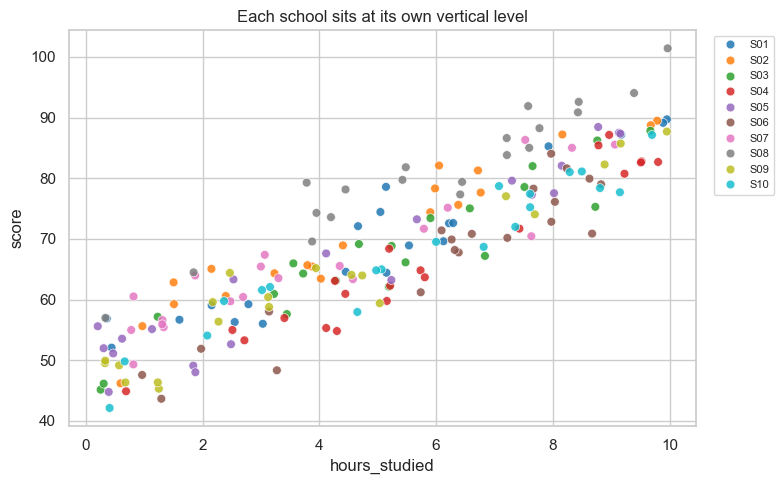

In [3]:
# Visualise the cluster structure
sns.scatterplot(data=students, x="hours_studied", y="score",
                hue="school", palette="tab10", s=40, alpha=0.85)
plt.title("Each school sits at its own vertical level")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()


Notice the colour bands stack at slightly different heights — that
is the **between-school variation** that OLS will pretend doesn't
exist.

### The two failed approaches, plotted side by side


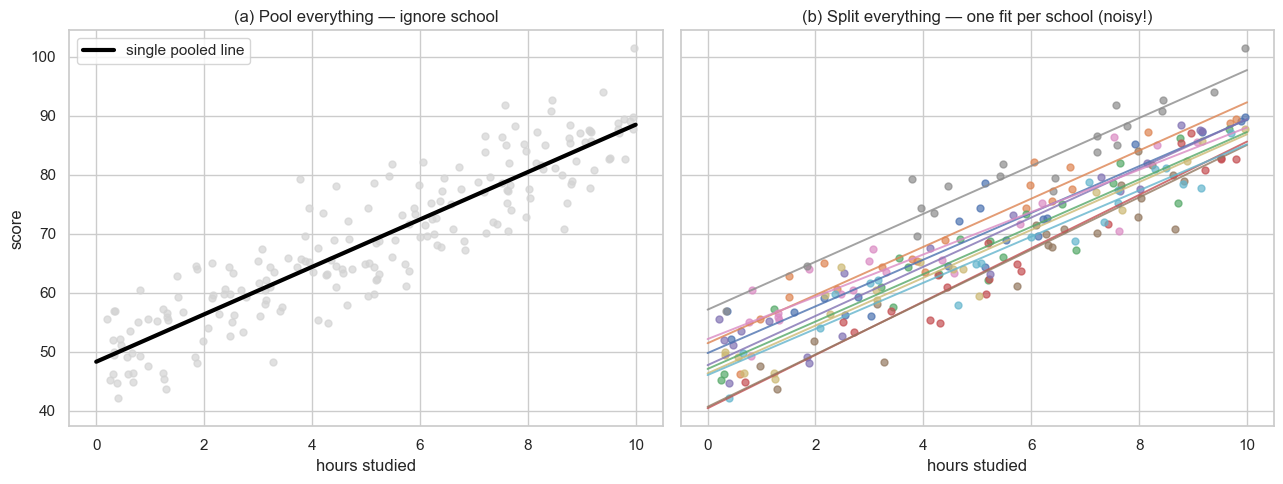

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# (a) Pool everything — one regression on all 200 students
pooled = smf.ols("score ~ hours_studied", data=students).fit()
x_grid = np.linspace(0, 10, 100)
axes[0].scatter(students["hours_studied"], students["score"],
                c="lightgray", s=25, alpha=0.7)
axes[0].plot(x_grid,
             pooled.params["Intercept"] + pooled.params["hours_studied"] * x_grid,
             color="black", lw=3, label="single pooled line")
axes[0].set_title("(a) Pool everything — ignore school")
axes[0].set_xlabel("hours studied"); axes[0].set_ylabel("score")
axes[0].legend()

# (b) Split everything — one regression per school
for s, sub in students.groupby("school"):
    fit = smf.ols("score ~ hours_studied", data=sub).fit()
    axes[1].scatter(sub["hours_studied"], sub["score"], s=25, alpha=0.7)
    axes[1].plot(x_grid,
                 fit.params["Intercept"] + fit.params["hours_studied"] * x_grid,
                 lw=1.4, alpha=0.8)
axes[1].set_title("(b) Split everything — one fit per school (noisy!)")
axes[1].set_xlabel("hours studied")

plt.tight_layout(); plt.show()


Approach (a) gives one tidy line but ignores the cluster structure
entirely — its standard errors will be wrong. Approach (b) lets every
school speak for itself but produces a noisy fan of lines, with no
shared population estimate. We want both at once.


## 3. The Mixed-Model Idea

A linear mixed model splits the linear predictor into two layers:

$$\boxed{\;
y_{ij} \;=\; \underbrace{\beta_0 + \beta_1 x_{ij}}_{\text{fixed effect — population pattern}}
\;+\; \underbrace{u_j}_{\text{random effect — school }j\text{'s offset}}
\;+\; \varepsilon_{ij}\;}$$

with two independent random pieces:

- $u_j \sim \mathcal{N}(0, \sigma_u^2)$ — every school has its own
  intercept shift, drawn from a normal centred at zero.
- $\varepsilon_{ij} \sim \mathcal{N}(0, \sigma^2)$ — student-level
  residual noise.

Reading the pieces:

- **Fixed effects** — the things we want a single, generalisable
  estimate of (the population intercept and slope).
- **Random effects** — cluster-specific deviations that we *don't*
  want to estimate one-by-one. Instead, we estimate the **distribution**
  they came from (its variance $\sigma_u^2$).

This way, each school's estimate gets **partially pulled** toward the
population mean, by an amount that depends on how much data the
school has and how variable schools are overall. This *partial
pooling* is exactly the smart middle path between approaches (a) and
(b).


## 4. Random Intercepts — First Worked Example

We fit the model

$$\text{score}_{ij} \;=\; \beta_0 + \beta_1 \text{hours}_{ij}
\;+\; u_j + \varepsilon_{ij}, \qquad u_j \sim \mathcal{N}(0, \sigma_u^2).$$

In `statsmodels` this is a one-liner: `mixedlm("score ~ hours_studied",
data, groups="school")`.


In [5]:
ri_model = smf.mixedlm("score ~ hours_studied",
                       data=students, groups=students["school"]).fit()
print(ri_model.summary())


         Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: score    
No. Observations:  200     Method:             REML     
No. Groups:        10      Scale:              13.9569  
Min. group size:   20      Log-Likelihood:     -562.9300
Max. group size:   20      Converged:          Yes      
Mean group size:   20.0                                 
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     48.015    1.435 33.457 0.000 45.203 50.828
hours_studied  4.074    0.095 42.772 0.000  3.887  4.261
Group Var     17.605    2.364                           



### Reading the summary

- **`Intercept`** — population baseline score when `hours_studied = 0`.
  Compare with our true intercept of 50.
- **`hours_studied`** — fixed-effect slope. Compare with our true slope
  of 4.
- **`Group Var`** — estimated variance $\hat\sigma_u^2$ between school
  intercepts. Its square root is the *standard deviation between
  schools* (compare with our true `school_sd = 6`).
- **`Scale`** — estimated within-school residual variance $\hat\sigma^2$.
  Its square root is the within-school SD (compare with `noise_sd = 4`).


In [6]:
print(f"True intercept     : {true_intercept:.2f}     fitted: {ri_model.fe_params['Intercept']:.2f}")
print(f"True slope         : {true_slope:.2f}      fitted: {ri_model.fe_params['hours_studied']:.2f}")
print(f"True school SD     : {school_sd:.2f}      fitted: {np.sqrt(ri_model.cov_re.iloc[0, 0]):.2f}")
print(f"True residual SD   : {noise_sd:.2f}      fitted: {np.sqrt(ri_model.scale):.2f}")


True intercept     : 50.00     fitted: 48.02
True slope         : 4.00      fitted: 4.07
True school SD     : 6.00      fitted: 4.20
True residual SD   : 4.00      fitted: 3.74


All four estimates are close to the truth. The mixed model has
**recovered the data-generating process** — both the population trend
and how much schools wiggle around it.

### Visualising the partial-pooling fit

Each school's predicted line is the **population line shifted by
that school's random intercept**. The bold black line is the
population fit (fixed effect alone).


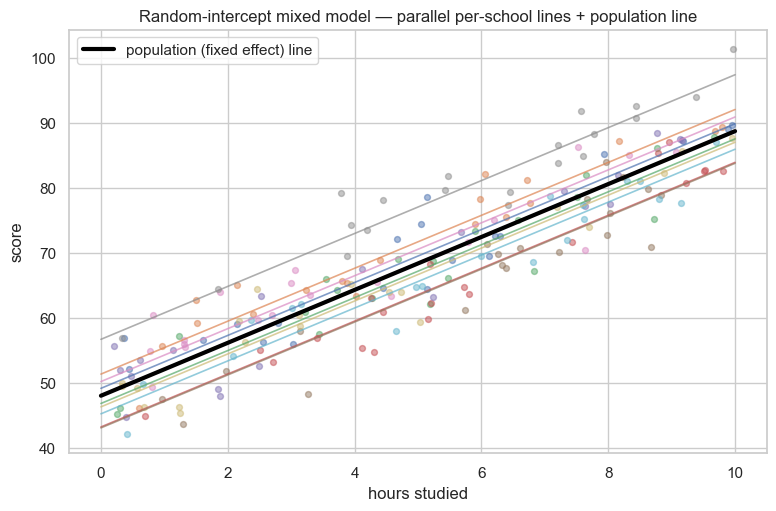

In [7]:
x_grid = np.linspace(0, 10, 100)
fixed_intercept = ri_model.fe_params["Intercept"]
fixed_slope     = ri_model.fe_params["hours_studied"]

# Random intercepts per school
re = ri_model.random_effects   # dict: school → Series with one entry 'Group'

plt.figure(figsize=(9, 5.5))
for school, sub in students.groupby("school"):
    plt.scatter(sub["hours_studied"], sub["score"], s=18, alpha=0.5)
    intercept_j = fixed_intercept + re[school]["Group"]
    plt.plot(x_grid, intercept_j + fixed_slope * x_grid,
             lw=1.2, alpha=0.7)
plt.plot(x_grid, fixed_intercept + fixed_slope * x_grid,
         color="black", lw=3, label="population (fixed effect) line")
plt.xlabel("hours studied"); plt.ylabel("score")
plt.title("Random-intercept mixed model — parallel per-school lines + population line")
plt.legend(); plt.show()


Notice the per-school lines are **parallel** — the random-intercept
model lets each school start at its own height but assumes the
*effect of an extra hour studied* is the same everywhere. What if
that's wrong?


## 5. Random Slopes — When the Effect Itself Varies by Cluster

Some schools may amplify the benefit of studying (great study halls,
supportive teachers) while others dampen it. The model that captures
this is

$$\text{score}_{ij} \;=\; (\beta_0 + u_{0j}) \;+\; (\beta_1 + u_{1j}) \text{hours}_{ij}
\;+\; \varepsilon_{ij},$$

where $(u_{0j}, u_{1j})$ are drawn jointly from a 2-D normal. In
`statsmodels` we add `re_formula="~ hours_studied"`:


In [8]:
# A new dataset where slopes really do vary by school
n_schools, n_per = 12, 20
true_intercept, true_slope = 50.0, 4.0
intercept_sd, slope_sd, noise_sd2 = 6.0, 1.5, 4.0

u0 = rng.normal(scale=intercept_sd, size=n_schools)   # intercept offsets
u1 = rng.normal(scale=slope_sd,     size=n_schools)   # slope offsets

rows = []
for s in range(n_schools):
    hours = rng.uniform(0, 10, size=n_per)
    score = (true_intercept + u0[s]
             + (true_slope + u1[s]) * hours
             + rng.normal(scale=noise_sd2, size=n_per))
    rows.append(pd.DataFrame({
        "school":        f"S{s+1:02d}",
        "hours_studied": hours,
        "score":         score,
    }))
students2 = pd.concat(rows, ignore_index=True)

rs_model = smf.mixedlm(
    "score ~ hours_studied",
    data=students2,
    groups=students2["school"],
    re_formula="~ hours_studied",
).fit(method="lbfgs")
print(rs_model.summary())


               Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     score    
No. Observations:      240         Method:                 REML     
No. Groups:            12          Scale:                  15.6629  
Min. group size:       20          Log-Likelihood:         -718.2268
Max. group size:       20          Converged:              No       
Mean group size:       20.0                                         
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                 51.458    2.829 18.188 0.000 45.913 57.004
hours_studied              3.564    0.590  6.040 0.000  2.407  4.720
Group Var                 92.775   17.774                           
Group x hours_studied Cov  3.348    6.793                           
hours_studied Var          4.071                  

/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 13.424993
  warnings.warn(msg, ConvergenceWarning)
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


The summary now shows **two random-effect variances** — one for the
intercept and one for the slope — plus their covariance. The fixed
slope (≈ 4) is the *average* effect of an extra study hour; some
schools beat that, others fall short.


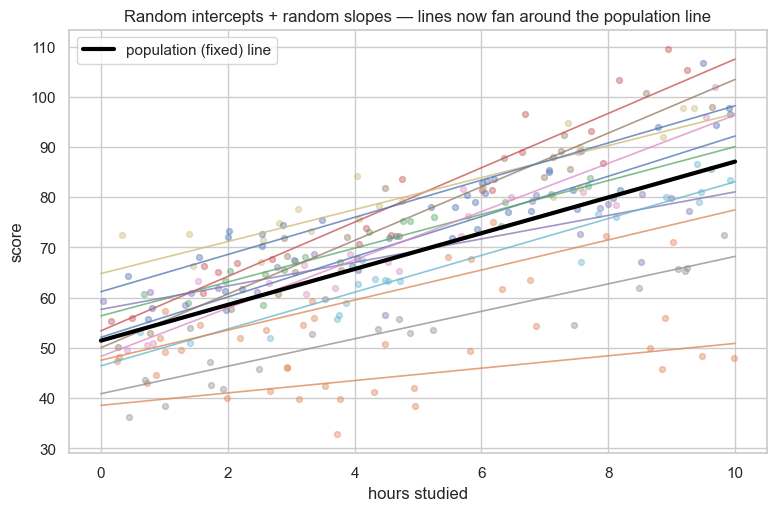

In [9]:
fixed_intercept = rs_model.fe_params["Intercept"]
fixed_slope     = rs_model.fe_params["hours_studied"]
re = rs_model.random_effects

x_grid = np.linspace(0, 10, 100)
plt.figure(figsize=(9, 5.5))
for school, sub in students2.groupby("school"):
    plt.scatter(sub["hours_studied"], sub["score"], s=18, alpha=0.4)
    int_j   = fixed_intercept + re[school]["Group"]
    slope_j = fixed_slope     + re[school]["hours_studied"]
    plt.plot(x_grid, int_j + slope_j * x_grid, lw=1.2, alpha=0.75)
plt.plot(x_grid, fixed_intercept + fixed_slope * x_grid,
         color="black", lw=3, label="population (fixed) line")
plt.xlabel("hours studied"); plt.ylabel("score")
plt.title("Random intercepts + random slopes — lines now fan around the population line")
plt.legend(); plt.show()


The lines no longer have to be parallel. Each school is allowed to
deviate *both* in baseline and in slope — but they are still pulled
toward the population trend rather than fitted in isolation.


## 6. ICC — How Clustered Are the Data?

Before reaching for a mixed model, it's worth asking: *do my data
really cluster, or is plain OLS fine?* The standard summary number is
the **Intraclass Correlation Coefficient (ICC)**:

$$\boxed{\;
\text{ICC} \;=\; \frac{\sigma_u^2}{\sigma_u^2 + \sigma^2}.\;
}$$

It's the share of total variation that lives **between** clusters
rather than **within** them. ICC = 0 means "no clustering, OLS is
fine." ICC = 1 means "all variation is between clusters."
Rule of thumb: anything above ~0.05 is worth a mixed model.


In [10]:
var_school   = float(ri_model.cov_re.iloc[0, 0])
var_residual = float(ri_model.scale)
icc = var_school / (var_school + var_residual)
print(f"Between-school variance: {var_school:.2f}")
print(f"Within-school variance : {var_residual:.2f}")
print(f"ICC                    : {icc:.3f}")
print(f"=> {icc:.0%} of the variation in scores is between schools — mixed model justified.")


Between-school variance: 17.60
Within-school variance : 13.96
ICC                    : 0.558
=> 56% of the variation in scores is between schools — mixed model justified.


## 7. Repeated-Measures Example — Patient Blood Pressure

Mixed models shine for **repeated measurements** where the same
subject is observed multiple times. Each subject *is* a cluster.

30 patients on a new blood-pressure medication, measured weekly for
8 weeks. The drug lowers BP on average, but each patient starts at
their own baseline.


In [11]:
n_patients = 30
weeks = np.arange(0, 8)
true_baseline = 140.0       # mean starting BP
true_week_effect = -1.5     # average drop per week
patient_sd = 8.0            # how much patients differ in baseline
noise_sd_bp = 3.0

patient_offsets = rng.normal(scale=patient_sd, size=n_patients)

rows = []
for p in range(n_patients):
    bp = (true_baseline + patient_offsets[p]
          + true_week_effect * weeks
          + rng.normal(scale=noise_sd_bp, size=len(weeks)))
    rows.append(pd.DataFrame({
        "patient": f"P{p+1:02d}",
        "week":    weeks,
        "bp":      bp,
    }))
bp_data = pd.concat(rows, ignore_index=True)
bp_data.head()


,patient,week,bp
0,P01,0,137.067279
1,P01,1,138.391783
2,P01,2,140.761139
3,P01,3,140.044204
4,P01,4,133.686686


In [12]:
bp_model = smf.mixedlm("bp ~ week", data=bp_data,
                       groups=bp_data["patient"]).fit()
print(bp_model.summary())


         Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: bp       
No. Observations:  240     Method:             REML     
No. Groups:        30      Scale:              8.5064   
Min. group size:   8       Log-Likelihood:     -655.9125
Max. group size:   8       Converged:          Yes      
Mean group size:   8.0                                  
--------------------------------------------------------
           Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
--------------------------------------------------------
Intercept 140.327    1.381 101.638 0.000 137.621 143.033
week       -1.383    0.082 -16.830 0.000  -1.544  -1.222
Group Var  53.642    5.256                              



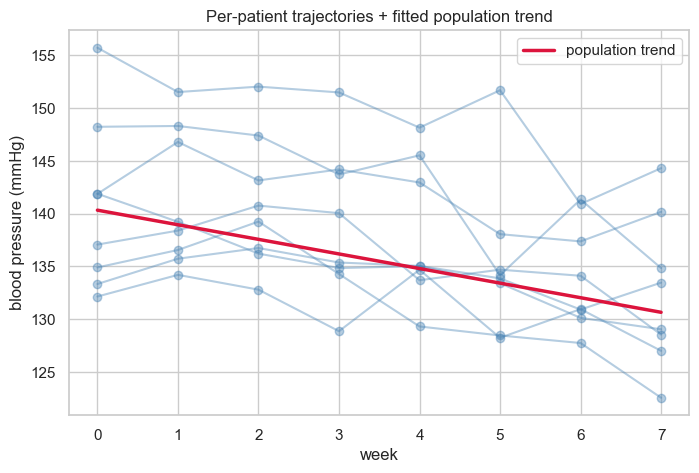

In [13]:
# Spaghetti plot: 8 random patients + the population trend
show = rng.choice(bp_data["patient"].unique(), size=8, replace=False)
for p in show:
    sub = bp_data[bp_data["patient"] == p]
    plt.plot(sub["week"], sub["bp"], color="steelblue", alpha=0.4, marker="o")

x_grid = np.linspace(0, 7, 100)
fix_b0, fix_b1 = bp_model.fe_params["Intercept"], bp_model.fe_params["week"]
plt.plot(x_grid, fix_b0 + fix_b1 * x_grid,
         color="crimson", lw=2.5, label="population trend")
plt.xlabel("week"); plt.ylabel("blood pressure (mmHg)")
plt.title("Per-patient trajectories + fitted population trend")
plt.legend(); plt.show()


Each patient's trajectory threads through their own typical level,
but the **overall downward trend** is the fixed effect that the drug
trial actually cares about. A simple `ols("bp ~ week")` would have
treated each weekly measurement as independent — a 30 × 8 = 240-row
study — and overstated the precision of the slope.


## 8. Mixed Models vs. ANOVA / ANCOVA

[ANOVA](ANOVA.md) treats each group as a *fixed* category — every
level of the factor is a hard-coded coefficient in the design matrix.
That's the right move when you have a small number of groups and you
want to talk about each one specifically.

Mixed models treat the grouping variable as a *random* draw from a
wider population of possible clusters. That's the right move when:

- The clusters are **not the focus** themselves (you don't really care
  about "School #07 vs. School #08" — you care about the population
  trend across *some sample of schools*).
- The same units are measured **repeatedly** over time.
- You want to **generalise** beyond the specific clusters in your
  sample.

Rule of thumb: handful of named groups → ANOVA-style fixed effects.
Many clusters that are samples from a wider population → random
effects.


## 9. Assumptions, Gotchas, and the GLMM Teaser

### Assumptions

1. **Random effects are normally distributed** with mean zero. Plot a
   histogram of the estimated `random_effects` to sanity-check.
2. **Linearity of the fixed effects.** Same as plain regression.
3. **Residuals are normal** with constant variance.
4. **Enough clusters** to estimate the random-effect variance —
   informal rule of thumb is **at least 5–10 clusters**, more is
   better. With only 2–3 clusters, treat them as fixed effects instead.

### Common gotchas

- **Convergence warnings** from `statsmodels` usually mean a random
   effect has near-zero variance — try dropping it (e.g. fit
   random-intercept-only instead of intercept + slope).
- **Singular fits** (`Group Var` reported as 0) often show up when the
   true between-cluster variance really is small. The data is telling
   you that ordinary regression would also be fine here.
- **Random vs. fixed interpretation.** Don't read individual random
   effects as if they were fixed-effect coefficients — they have been
   shrunk toward zero by the mixed model. They are *predictions*, not
   tests.

### Where to next — GLMMs

Everything above assumed a **Normal** outcome. What if your outcome is
binary (did the patient relapse?), count (how many doctor visits?), or
skewed positive (waiting time)? You combine the
[GLM machinery](GLM.md) with random effects to get a **Generalized
Linear Mixed Model (GLMM)**:

$$g(\mu_{ij}) \;=\; \beta_0 + \beta_1 x_{ij} + u_j,
\qquad u_j \sim \mathcal{N}(0, \sigma_u^2),$$

where $g(\cdot)$ is the same link function from the GLM notebook —
logit for binary outcomes, log for counts. In Python, look at
`statsmodels.genmod.bayes_mixed_glm.BinomialBayesMixedGLM` or the
popular `pymer4` and `bambi` packages. The intuition stays the same:
a population pattern plus cluster-specific random shifts.


## 10. Key Takeaways

1. **Plain OLS assumes independent rows.** Clustered, hierarchical, or
   repeated-measures data violates this and gives p-values that are
   too small.
2. A linear mixed model splits the predictor into **fixed effects**
   (population pattern) and **random effects** (cluster-specific
   deviations drawn from a normal distribution).
3. **Random intercepts** let each cluster sit at its own level;
   **random slopes** let the predictor's effect itself vary by
   cluster.
4. **Partial pooling** is the magic — each cluster's estimate is
   pulled toward the population mean, smarter than "pool everything"
   or "split everything."
5. The **ICC** quantifies how clustered the data are; above ~0.05 a
   mixed model is worth it.
6. In `statsmodels`, fitting one is a one-liner:
   `smf.mixedlm(formula, data, groups=cluster_col, re_formula=...).fit()`.
7. For non-Gaussian outcomes (binary, count, etc.), the same idea
   extends to **Generalized Linear Mixed Models (GLMMs)**.


## 11. Practice Exercises

1. **Random-intercept on farms.** Synthesise a dataset of 8 farms,
   each with 25 plots. Each farm has its own baseline soil quality
   (random intercept). The fixed effect of interest is fertilizer
   amount on yield. Fit the model and report the population slope.
2. **Add a random slope to the BP example.** Modify the §7
   simulation so each patient has their own *response rate* to the
   medication (some respond more, some less). Fit
   `mixedlm("bp ~ week", data, groups="patient", re_formula="~ week")`
   and compare against the random-intercept-only fit.
3. **ICC for a third dataset.** Build a synthetic dataset of 15
   classrooms × 30 students where between-classroom variance is
   *small* compared to within. Compute the ICC and decide whether a
   mixed model is justified.
